In [366]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import pickle


## Exporting the data path from the files

In [367]:
data_path = Path.cwd().parent / 'data' / 'raw' / 'Telco-Customer-Churn.csv'
df = pd.read_csv(data_path)
pd.set_option('display.max_columns', None)

In [368]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [369]:
df.MultipleLines.unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [370]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [371]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [372]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [373]:
df.shape

(7043, 21)

In [374]:
df=df.drop('customerID',axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [375]:
num_cols=['tenure','MonthlyCharges','TotalCharges',]
for i in df.columns:
    if i not in num_cols:  
        print(df[i].unique())
        print('-'*20)

['Female' 'Male']
--------------------
[0 1]
--------------------
['Yes' 'No']
--------------------
['No' 'Yes']
--------------------
['No' 'Yes']
--------------------
['No phone service' 'No' 'Yes']
--------------------
['DSL' 'Fiber optic' 'No']
--------------------
['No' 'Yes' 'No internet service']
--------------------
['Yes' 'No' 'No internet service']
--------------------
['No' 'Yes' 'No internet service']
--------------------
['No' 'Yes' 'No internet service']
--------------------
['No' 'Yes' 'No internet service']
--------------------
['No' 'Yes' 'No internet service']
--------------------
['Month-to-month' 'One year' 'Two year']
--------------------
['Yes' 'No']
--------------------
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
--------------------
['No' 'Yes']
--------------------


In [376]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [377]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [378]:
df.TotalCharges=df.TotalCharges.replace(' ',0)

In [379]:
df.TotalCharges=df.TotalCharges.astype('float64')

In [380]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### cleaning overview
missing values in total charge was replaced with 0

customer id was removed 

class imbalance detected in the target


# EDA

In [381]:
df.shape

(7043, 20)

In [382]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [383]:
def create_tenure_group(tenure):
    if tenure <= 12:
        return '0-12'
    elif tenure <= 24:
        return '13-24'
    elif tenure <= 48:
        return '25-48'
    else:
        return '49-72'
df['tenure_group'] = df['tenure'].apply(create_tenure_group)

In [384]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [385]:
df['total_services'] = 0
df['total_services'] += (df['PhoneService'] == 'Yes').astype(int)
df['total_services'] += (df['MultipleLines'] == 'Yes').astype(int)
df['total_services'] += (df['InternetService'] != 'No').astype(int)
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df['total_services'] += (df[col] == 'Yes').astype(int)
df['total_services'].value_counts()

total_services
1    1264
4     965
5     922
6     908
2     859
3     846
7     676
8     395
9     208
Name: count, dtype: int64

In [386]:
df['has_any_security'] = ((df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')).astype(int)

df['has_any_backup'] = ((df['OnlineBackup'] == 'Yes') | (df['DeviceProtection'] == 'Yes')).astype(int)

df['is_long_term'] = (df['Contract'].isin(['One year', 'Two year'])).astype(int)

In [387]:
df['avg_monthly_charges'] = df['TotalCharges'] / (df['tenure'] + 1)

df['charges_per_service'] = df['MonthlyCharges'] / (df['total_services'] + 1)

df['paperless_electronic'] = ((df['PaperlessBilling'] == 'Yes') & 
                               (df['PaymentMethod'] == 'Electronic check')).astype(int)

In [388]:
df['tenure_monthly_interaction'] = df['tenure'] * df['MonthlyCharges']

In [389]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,has_any_security,has_any_backup,is_long_term,avg_monthly_charges,charges_per_service,paperless_electronic,tenure_monthly_interaction
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12,2,0,1,0,14.925000,9.950000,1,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48,4,1,1,1,53.985714,11.390000,0,1936.30
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12,4,1,1,0,36.050000,10.770000,0,107.70
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48,4,1,1,1,40.016304,8.460000,0,1903.50
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12,2,0,0,0,50.550000,23.566667,1,141.40


C:\Users\TUF F16\AppData\Local\Temp\ipykernel_16916\1828836855.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_churn.index, y=contract_churn.values, palette='viridis', ax=ax1)
C:\Users\TUF F16\AppData\Local\Temp\ipykernel_16916\1828836855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_churn.index, y=payment_churn.values, palette='viridis', ax=ax2)
C:\Users\TUF F16\AppData\Local\Temp\ipykernel_16916\1828836855.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palet

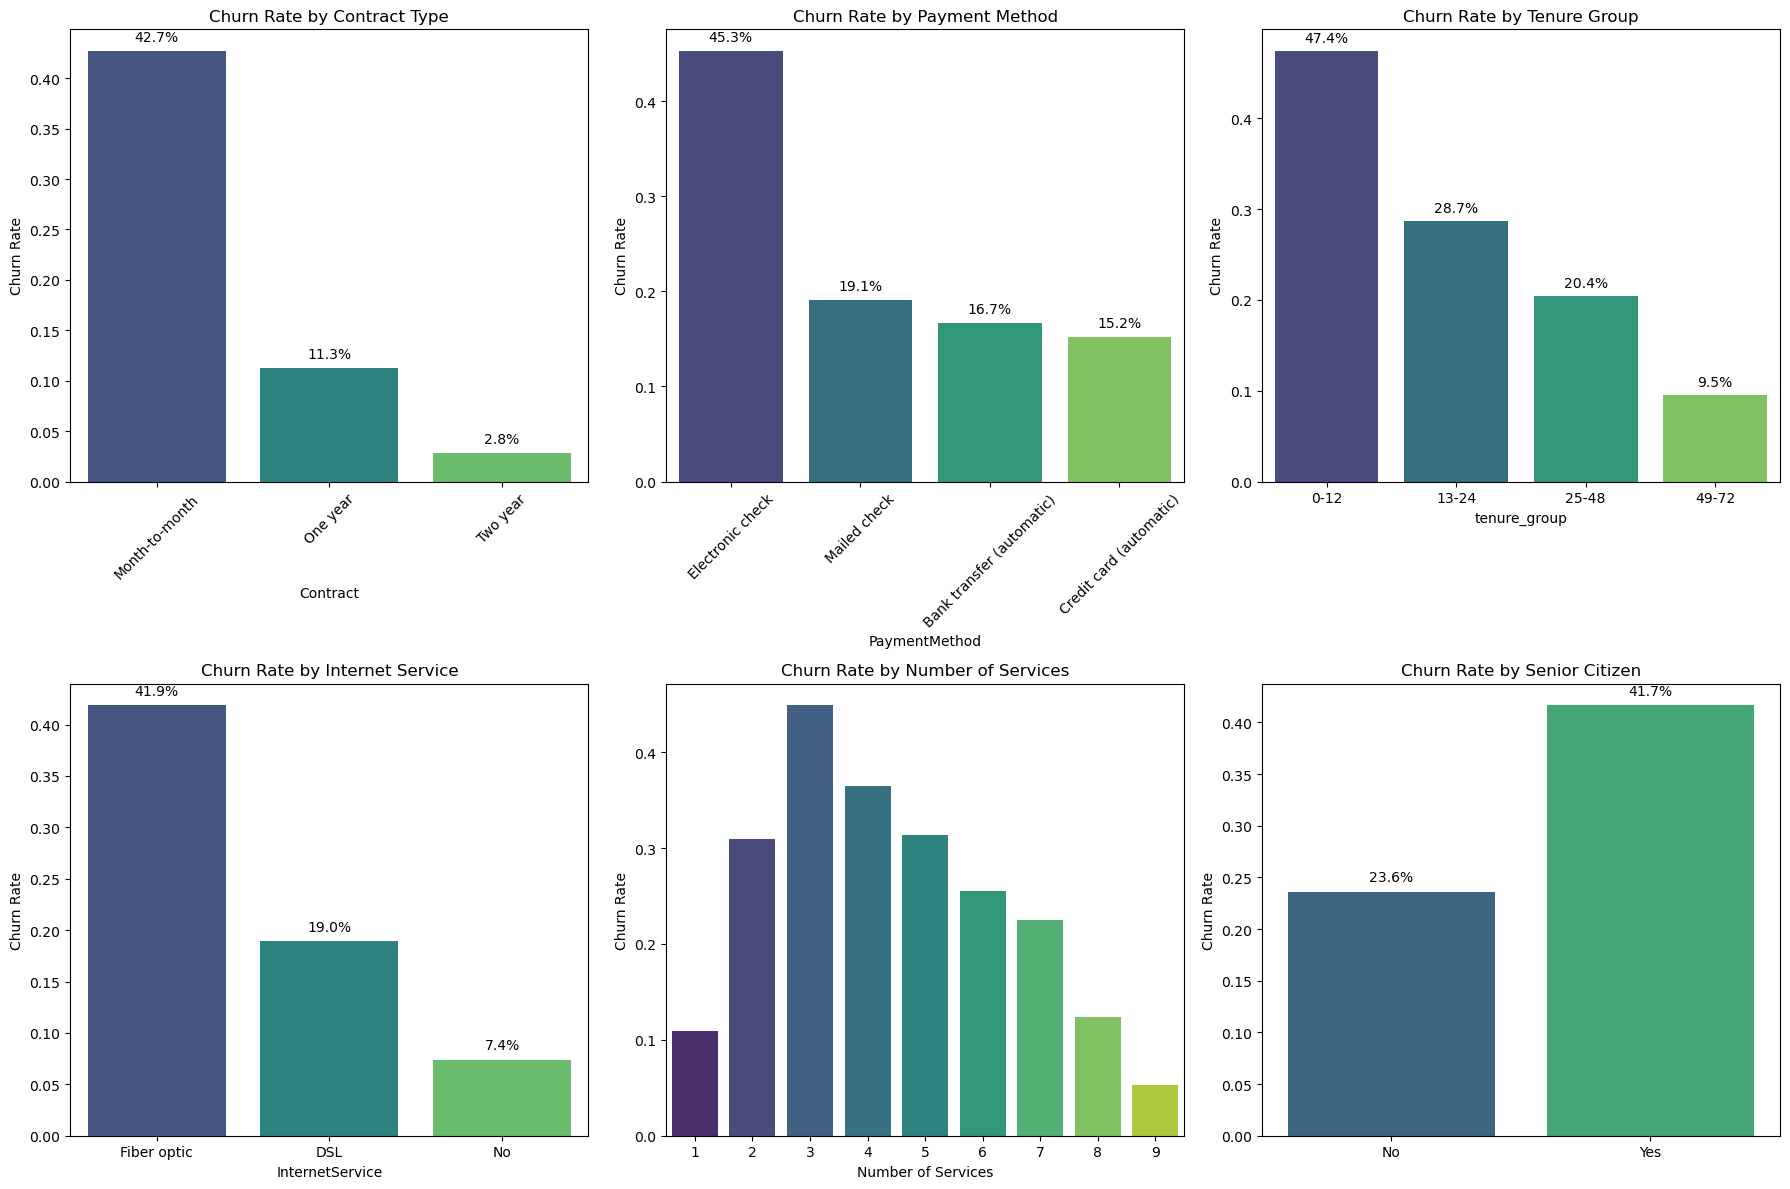


=== Key Insights ===
Month-to-month contracts: 42.7% churn rate
Two-year contracts: 2.8% churn rate
Electronic check: 45.3% churn rate
New customers (0-12 months): 47.4% churn rate


In [390]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ax1 = axes[0, 0]
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
sns.barplot(x=contract_churn.index, y=contract_churn.values, palette='viridis', ax=ax1)
ax1.set_title('Churn Rate by Contract Type', fontsize=12)
ax1.set_ylabel('Churn Rate')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(contract_churn.values):
    ax1.text(i, v + 0.01, f'{v:.1%}', ha='center')

ax2 = axes[0, 1]
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
sns.barplot(x=payment_churn.index, y=payment_churn.values, palette='viridis', ax=ax2)
ax2.set_title('Churn Rate by Payment Method', fontsize=12)
ax2.set_ylabel('Churn Rate')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(payment_churn.values):
    ax2.text(i, v + 0.01, f'{v:.1%}', ha='center')

ax3 = axes[0, 2]
tenure_order = ['0-12', '13-24', '25-48', '49-72']
tenure_churn = df.groupby('tenure_group')['Churn'].mean().reindex(tenure_order)
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette='viridis', ax=ax3)
ax3.set_title('Churn Rate by Tenure Group', fontsize=12)
ax3.set_ylabel('Churn Rate')
for i, v in enumerate(tenure_churn.values):
    ax3.text(i, v + 0.01, f'{v:.1%}', ha='center')

ax4 = axes[1, 0]
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
sns.barplot(x=internet_churn.index, y=internet_churn.values, palette='viridis', ax=ax4)
ax4.set_title('Churn Rate by Internet Service', fontsize=12)
ax4.set_ylabel('Churn Rate')
for i, v in enumerate(internet_churn.values):
    ax4.text(i, v + 0.01, f'{v:.1%}', ha='center')

ax5 = axes[1, 1]
services_churn = df.groupby('total_services')['Churn'].mean()
sns.barplot(x=services_churn.index, y=services_churn.values, palette='viridis', ax=ax5)
ax5.set_title('Churn Rate by Number of Services', fontsize=12)
ax5.set_xlabel('Number of Services')
ax5.set_ylabel('Churn Rate')

ax6 = axes[1, 2]
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean()
sns.barplot(x=['No', 'Yes'], y=senior_churn.values, palette='viridis', ax=ax6)
ax6.set_title('Churn Rate by Senior Citizen', fontsize=12)
ax6.set_ylabel('Churn Rate')
for i, v in enumerate(senior_churn.values):
    ax6.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

print("\n=== Key Insights ===")
print(f"Month-to-month contracts: {contract_churn['Month-to-month']:.1%} churn rate")
print(f"Two-year contracts: {contract_churn['Two year']:.1%} churn rate")
print(f"Electronic check: {payment_churn['Electronic check']:.1%} churn rate")
print(f"New customers (0-12 months): {tenure_churn['0-12']:.1%} churn rate")

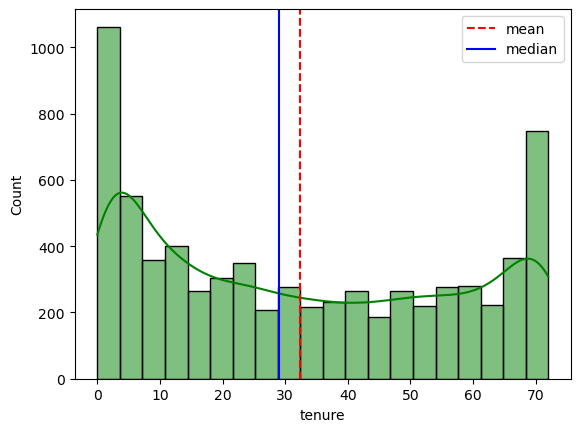

In [391]:
sns.histplot(df['tenure'],kde=True,bins=20,color='green')
mean=df['tenure'].mean()
median=df['tenure'].median()
plt.axvline([mean],color='red',linestyle='dashed',label='mean')
plt.axvline([median],color='blue',label='median')
plt.legend()

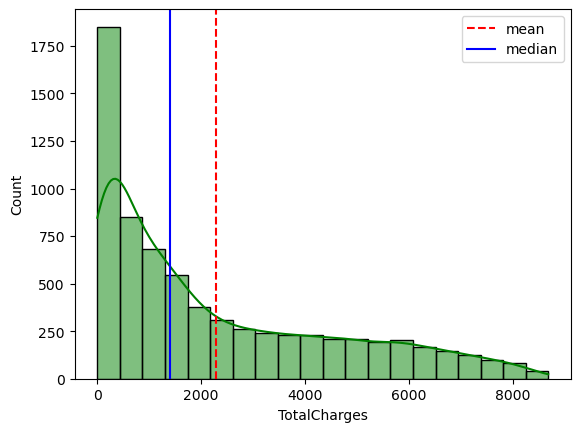

In [392]:
sns.histplot(df['TotalCharges'],kde=True,bins=20,color='green')
mean=df['TotalCharges'].mean()
median=df['TotalCharges'].median()
plt.axvline([mean],color='red',linestyle='dashed',label='mean')
plt.axvline([median],color='blue',label='median')
plt.legend()

<Axes: >

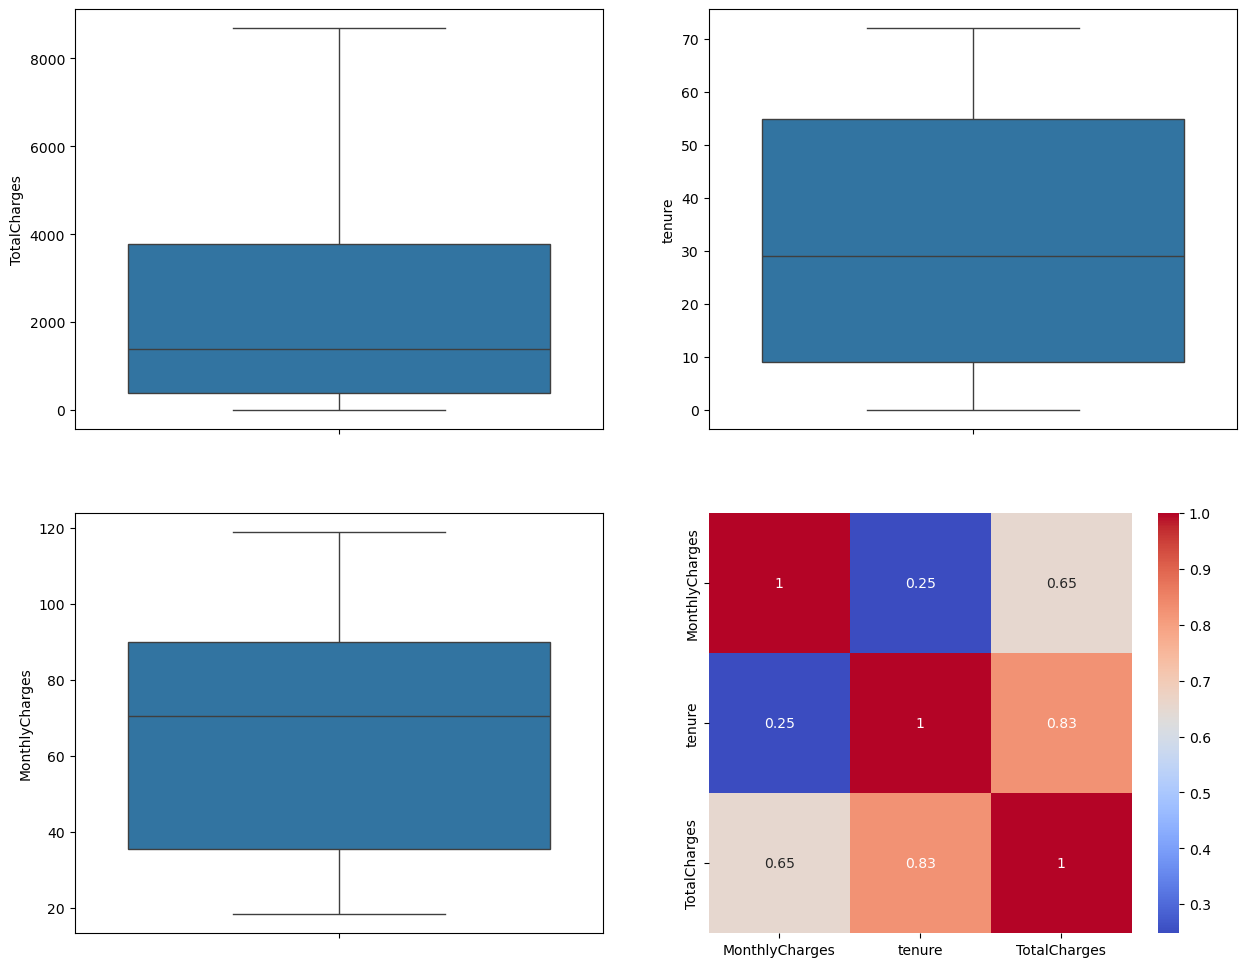

In [393]:
fig,axes = plt.subplots(2,2,figsize=(15,12))
sns.boxplot(y=df['TotalCharges'], ax=axes[0,0])
sns.boxplot(y=df['tenure'], ax=axes[0,1])
sns.boxplot(y=df['MonthlyCharges'], ax=axes[1,0])
sns.heatmap(df[['MonthlyCharges','tenure','TotalCharges']].corr(),annot=True,cmap='coolwarm',ax=axes[1,1])



In [394]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      7043 non-null   object 
 1   SeniorCitizen               7043 non-null   int64  
 2   Partner                     7043 non-null   object 
 3   Dependents                  7043 non-null   object 
 4   tenure                      7043 non-null   int64  
 5   PhoneService                7043 non-null   object 
 6   MultipleLines               7043 non-null   object 
 7   InternetService             7043 non-null   object 
 8   OnlineSecurity              7043 non-null   object 
 9   OnlineBackup                7043 non-null   object 
 10  DeviceProtection            7043 non-null   object 
 11  TechSupport                 7043 non-null   object 
 12  StreamingTV                 7043 non-null   object 
 13  StreamingMovies             7043 

In [395]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group',
       'total_services', 'has_any_security', 'has_any_backup', 'is_long_term',
       'avg_monthly_charges', 'charges_per_service', 'paperless_electronic',
       'tenure_monthly_interaction'],
      dtype='object')

In [396]:
obj_columns = df.select_dtypes(include='object').columns.tolist()
print(f"Encoding {len(obj_columns)} categorical columns...")

encoder_col = {}
df_encoded = df.copy()

for col in obj_columns:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(df_encoded[col])
    encoder_col[col] = encoder

print(f"Encoded shape: {df_encoded.shape}")

Encoding 16 categorical columns...
Encoded shape: (7043, 29)


In [397]:
df=df_encoded

# Data Preprocessing

In [398]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,has_any_security,has_any_backup,is_long_term,avg_monthly_charges,charges_per_service,paperless_electronic,tenure_monthly_interaction
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0,0,2,0,1,0,14.925000,9.950000,1,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0,2,4,1,1,1,53.985714,11.390000,0,1936.30
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1,0,4,1,1,0,36.050000,10.770000,0,107.70
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0,2,4,1,1,1,40.016304,8.460000,0,1903.50
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1,0,2,0,0,0,50.550000,23.566667,1,141.40


label encoding on categorical values


<Axes: >

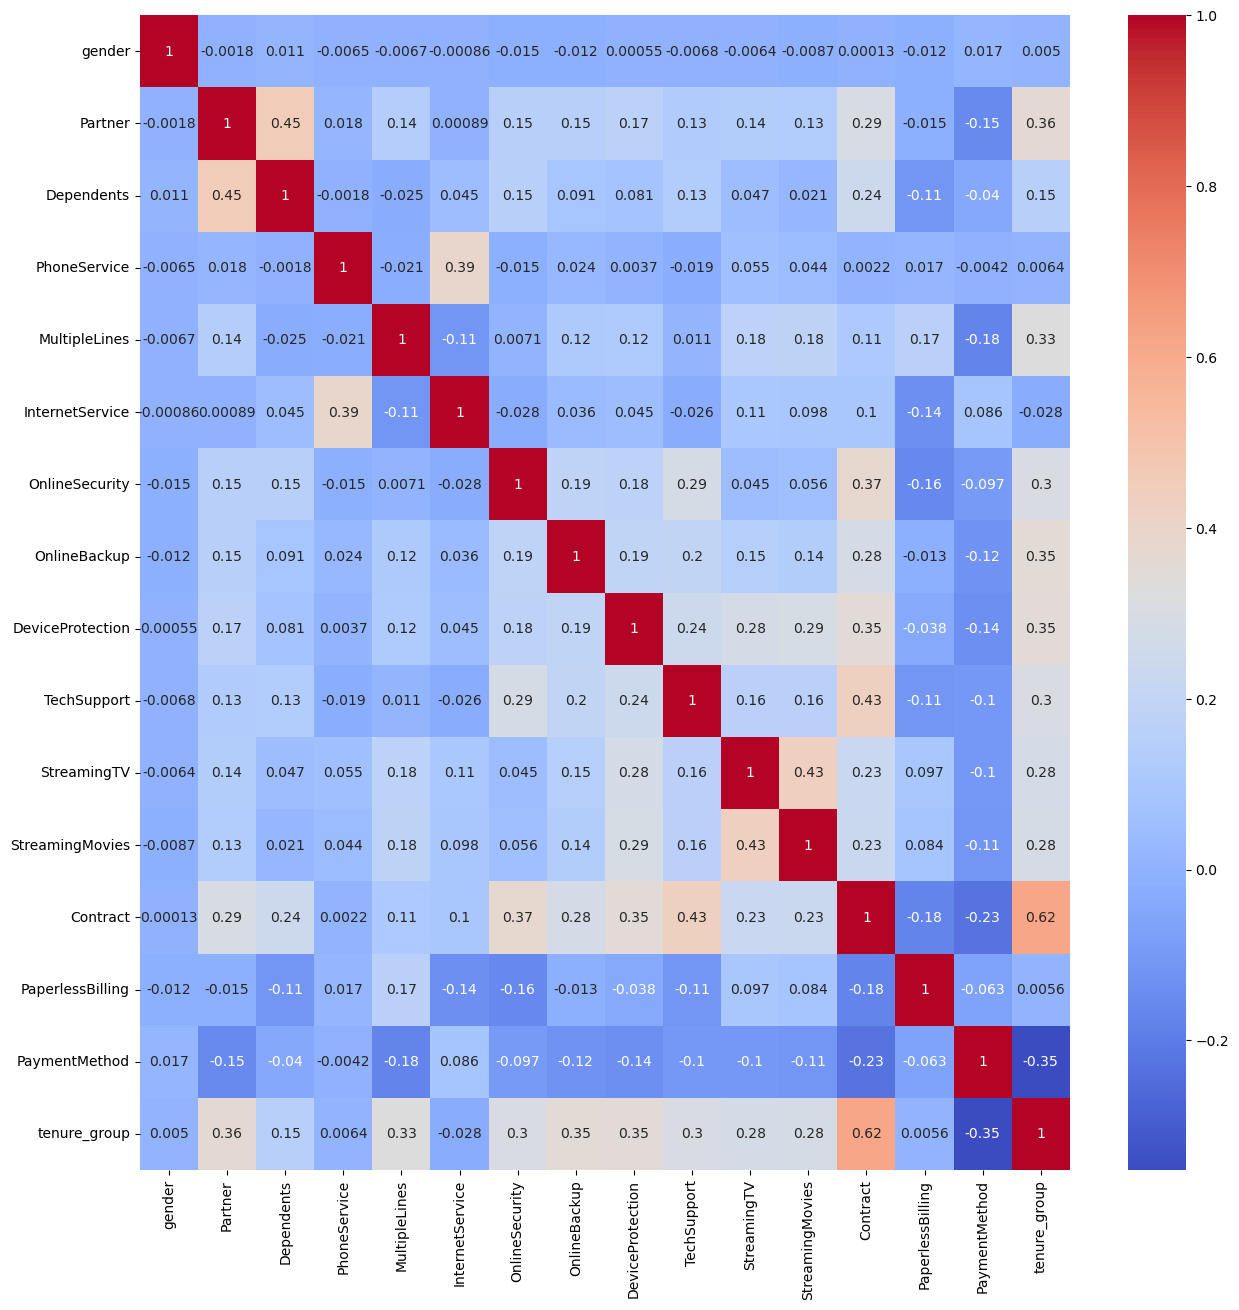

In [399]:
plt.figure(figsize=(15,15))
sns.heatmap(df[obj_columns].corr(),annot=True,cmap='coolwarm',)

In [400]:
corr_rank = df.corr(numeric_only=True)['Churn'].abs().sort_values(ascending=False)
print(corr_rank)

Churn                         1.000000
is_long_term                  0.405103
charges_per_service           0.398503
Contract                      0.396713
tenure                        0.352229
tenure_group                  0.345410
paperless_electronic          0.301646
OnlineSecurity                0.289309
TechSupport                   0.282492
tenure_monthly_interaction    0.198514
TotalCharges                  0.198324
OnlineBackup                  0.195525
MonthlyCharges                0.193356
PaperlessBilling              0.191825
has_any_security              0.182744
DeviceProtection              0.178134
Dependents                    0.164221
SeniorCitizen                 0.150889
Partner                       0.150448
PaymentMethod                 0.107062
avg_monthly_charges           0.072579
has_any_backup                0.059525
InternetService               0.047291
StreamingMovies               0.038492
MultipleLines                 0.038037
StreamingTV              

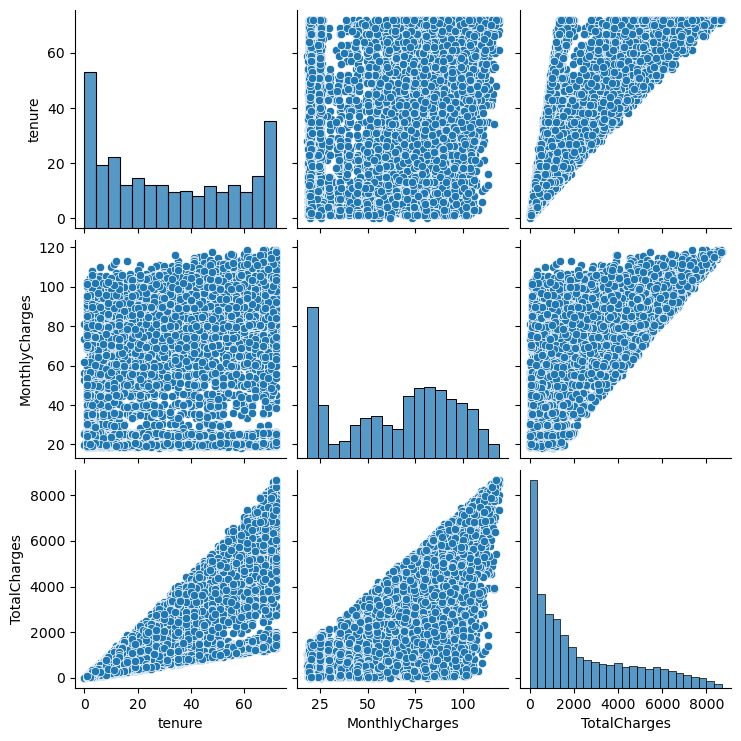

In [401]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges']])

In [402]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,has_any_security,has_any_backup,is_long_term,avg_monthly_charges,charges_per_service,paperless_electronic,tenure_monthly_interaction
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0,0,2,0,1,0,14.925000,9.950000,1,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0,2,4,1,1,1,53.985714,11.390000,0,1936.30
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1,0,4,1,1,0,36.050000,10.770000,0,107.70
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0,2,4,1,1,1,40.016304,8.460000,0,1903.50
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1,0,2,0,0,0,50.550000,23.566667,1,141.40


saving to processed file

In [403]:
df.gender.value_counts()

gender
1    3555
0    3488
Name: count, dtype: int64

In [404]:
path=Path.cwd().parent/'data'/'processed'
df.to_csv(path/'preprocessed.csv',index=False)

### Train and test split

In [405]:
from sklearn.preprocessing import StandardScaler
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE: {X_train_resampled.shape}")
print(f"Class distribution: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Training set: (5634, 28)
Test set: (1409, 28)
After SMOTE: (8278, 28)
Class distribution: {0: 4139, 1: 4139}


## Model Training

In [406]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
neg = (y_train_resampled == 0).sum()
pos = (y_train_resampled == 1).sum()
scale = neg / pos

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training XGBoost with hyperparameter tuning...")
xgb_params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6,7,8,9,10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.7, 0.8, 0.9, 1.0, 1.1, 1.2],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
}

xgb_base = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_random = RandomizedSearchCV(
    xgb_base, 
    xgb_params, 
    n_iter=10, 
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_resampled, y_train_resampled)
print(f"Best XGBoost params: {xgb_random.best_params_}")
print(f"Best XGBoost CV score: {xgb_random.best_score_:.4f}")

models = {'XGBoost': xgb_random.best_estimator_}

Training XGBoost with hyperparameter tuning...


c:\Users\TUF F16\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
40 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\TUF F16\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\TUF F16\anaconda3\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
  File "c:\Users\TUF F16\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1806, in fit
    self._Booster = train(
                   

Best XGBoost params: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best XGBoost CV score: 0.9393


In [407]:
from sklearn.ensemble import GradientBoostingClassifier
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_scores = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=cv, scoring='roc_auc')
print(f"Random Forest CV ROC-AUC: {np.mean(rf_scores):.4f}")
rf_model.fit(X_train_resampled, y_train_resampled)
models['Random Forest'] = rf_model

print("\nTraining Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_scores = cross_val_score(gb_model, X_train_resampled, y_train_resampled, cv=cv, scoring='roc_auc')
print(f"Gradient Boosting CV ROC-AUC: {np.mean(gb_scores):.4f}")
gb_model.fit(X_train_resampled, y_train_resampled)
models['Gradient Boosting'] = gb_model


Training Random Forest...
Random Forest CV ROC-AUC: 0.9068

Training Gradient Boosting...
Gradient Boosting CV ROC-AUC: 0.9369


In [408]:
from sklearn.ensemble import VotingClassifier
print("\nTraining Voting Classifier...")
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', models['XGBoost']),
        ('rf', models['Random Forest']),
        ('gb', models['Gradient Boosting'])
    ],
    voting='soft'
)
voting_scores = cross_val_score(voting_clf, X_train_resampled, y_train_resampled, cv=cv, scoring='roc_auc')
print(f"Voting Classifier CV ROC-AUC: {np.mean(voting_scores):.4f}")
voting_clf.fit(X_train_resampled, y_train_resampled)
models['Voting Ensemble'] = voting_clf


Training Voting Classifier...


c:\Users\TUF F16\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:51:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\TUF F16\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:51:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\TUF F16\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:51:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\TUF F16\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:52:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.up

Voting Classifier CV ROC-AUC: 0.9365


c:\Users\TUF F16\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:52:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Model Evaluation

In [409]:
from sklearn.metrics import accuracy_score, roc_auc_score
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {'accuracy': accuracy, 'roc_auc': roc_auc}
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = models[best_model_name]

print(f"\n{'=' * 60}")
print(f"Best Model: {best_model_name}")
print(f"ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"{'=' * 60}")

MODEL COMPARISON

XGBoost:
  Accuracy: 0.7835
  ROC-AUC: 0.8260

Random Forest:
  Accuracy: 0.7686
  ROC-AUC: 0.8406

Gradient Boosting:
  Accuracy: 0.7715
  ROC-AUC: 0.8285

Voting Ensemble:
  Accuracy: 0.7814
  ROC-AUC: 0.8363

Best Model: Random Forest
ROC-AUC: 0.8406


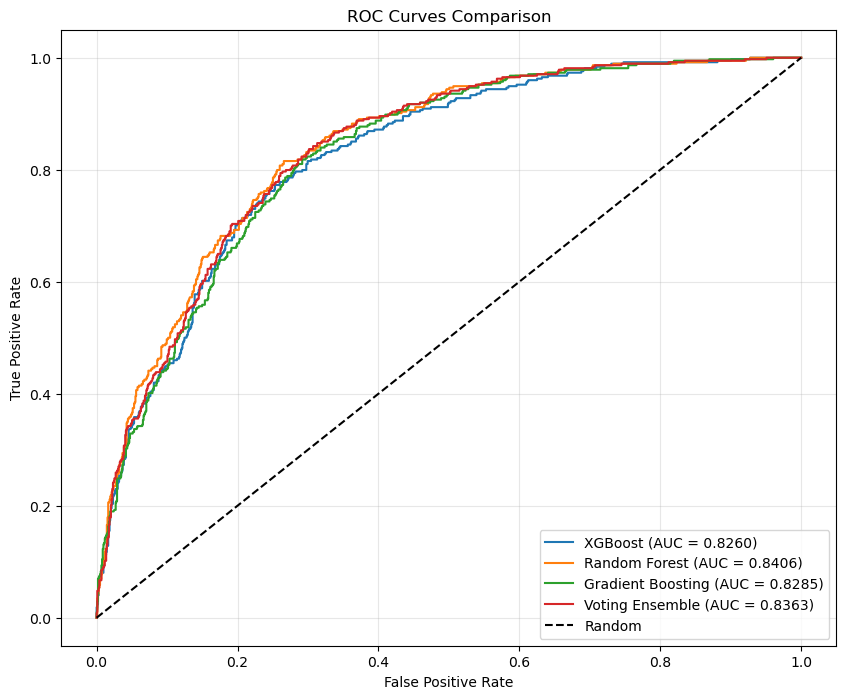

In [410]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [411]:
from sklearn.metrics import f1_score, recall_score

print("=== Additional evaluation ===")
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    print(f"\n{name}:")
    print(f"  F1 score : {f1:.4f}")
    print(f"  Recall   : {rec:.4f}")

=== Additional evaluation ===

XGBoost:
  F1 score : 0.5862
  Recall   : 0.5775

Random Forest:
  F1 score : 0.6244
  Recall   : 0.7246

Gradient Boosting:
  F1 score : 0.5672
  Recall   : 0.5642

Voting Ensemble:
  F1 score : 0.5979
  Recall   : 0.6123


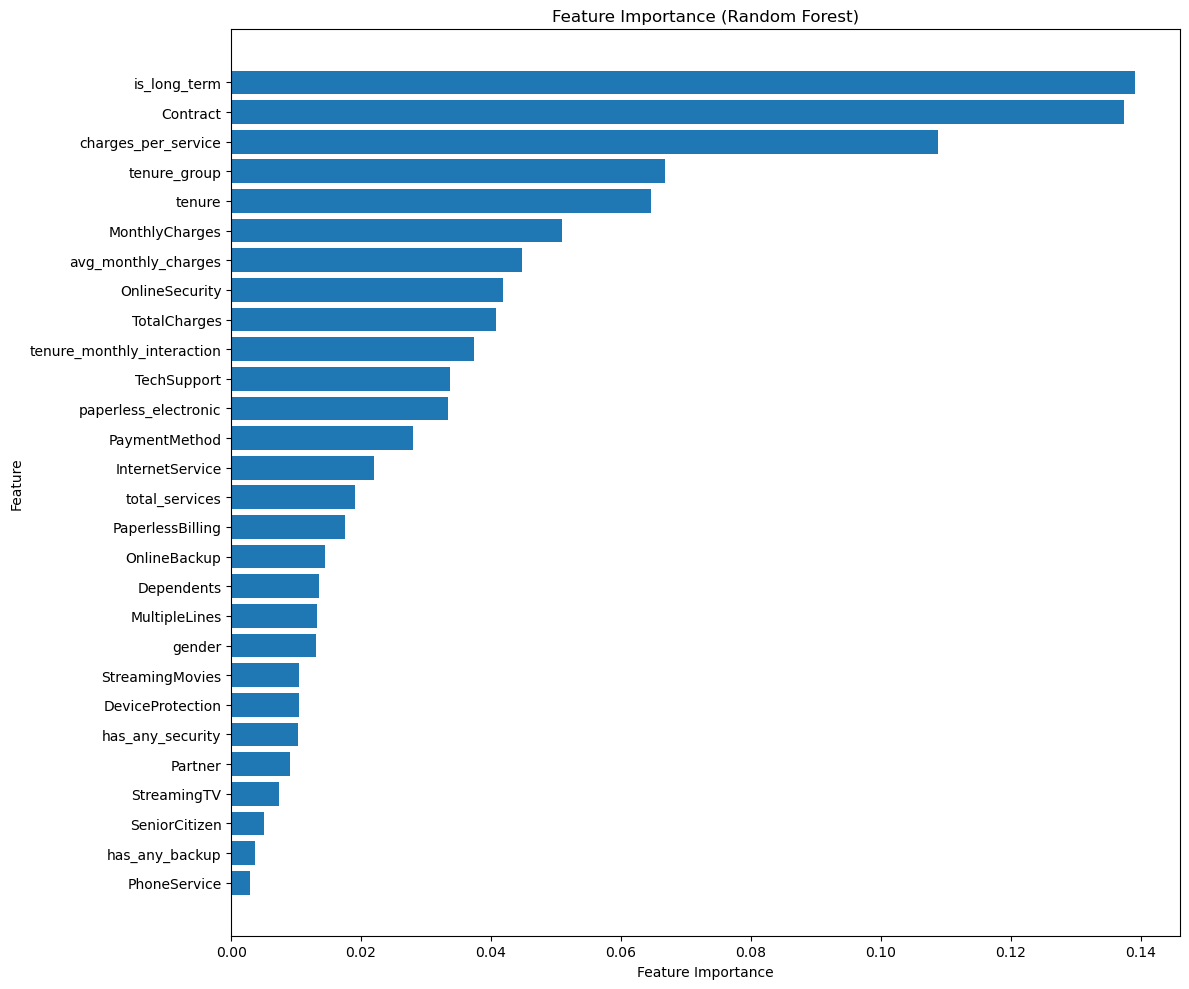


Top 10 Most Important Features:
                   feature  importance
tenure_monthly_interaction    0.037453
              TotalCharges    0.040809
            OnlineSecurity    0.041825
       avg_monthly_charges    0.044817
            MonthlyCharges    0.050995
                    tenure    0.064604
              tenure_group    0.066748
       charges_per_service    0.108797
                  Contract    0.137463
              is_long_term    0.139119


In [412]:
plt.figure(figsize=(12, 10))

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(f'Feature Importance ({best_model_name})')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.tail(10)[['feature', 'importance']].to_string(index=False))

In [413]:
model_data = {
    'model': best_model,
    'all_models': models,
    'features': X.columns.tolist(),
    'encoder': encoder_col,
    'scaler': scaler,
    'best_model_name': best_model_name,
    'results': results
}

save_path = Path.cwd().parent / 'models' / 'Customer_Churn_Model.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"Model saved to: {save_path}")
print(f"\nModel details:")
print(f"  - Best model: {best_model_name}")
print(f"  - ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"  - Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  - Number of features: {len(X.columns)}")

Model saved to: c:\Users\TUF F16\Documents\Customer-Churn-Prediction-Using-Machine-Learning\models\Customer_Churn_Model.pkl

Model details:
  - Best model: Random Forest
  - ROC-AUC: 0.8406
  - Accuracy: 0.7686
  - Number of features: 28


Random forest has higher accuracy than others

Saving the trained model

In [414]:
model_data = {
    'model': best_model,
    'all_models': models,
    'features': X.columns.tolist(),
    'encoder': encoder_col,
    'scaler': scaler,
    'best_model_name': best_model_name,
    'results': results
}

save_path = Path.cwd().parent / 'models' / 'Customer_Churn_Model.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"Model saved to: {save_path}")
print(f"\nModel details:")
print(f"  - Best model: {best_model_name}")
print(f"  - ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"  - Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  - Number of features: {len(X.columns)}")

Model saved to: c:\Users\TUF F16\Documents\Customer-Churn-Prediction-Using-Machine-Learning\models\Customer_Churn_Model.pkl

Model details:
  - Best model: Random Forest
  - ROC-AUC: 0.8406
  - Accuracy: 0.7686
  - Number of features: 28


loading the model

In [415]:
with open(save_path,'rb') as f:
    model_data = pickle.load(f)
    best_model = model_data['model']
    X.columns = model_data['features']
    encoder_col = model_data['encoder']
    scaler = model_data['scaler']
    best_model_name = model_data['best_model_name']
    results = model_data['results']

 

In [416]:
print(f"Model loaded from: {save_path}")
print(f"\nModel details:")
print(f"  - Best model: {best_model_name}")
print(f"  - ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"  - Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  - Number of features: {len(X.columns)}")


Model loaded from: c:\Users\TUF F16\Documents\Customer-Churn-Prediction-Using-Machine-Learning\models\Customer_Churn_Model.pkl

Model details:
  - Best model: Random Forest
  - ROC-AUC: 0.8406
  - Accuracy: 0.7686
  - Number of features: 28


In [ ]:
import mlflow
import mlflow.sklearn



with open(save_path, "wb") as f:
    pickle.dump(model_data, f)

mlflow.set_tracking_uri("http://localhost:5000")  
 
mlflow.set_experiment("Customer Churn Prediction")
    
with mlflow.start_run(run_name=best_model_name):
        mlflow.log_param("best_model", best_model_name)
        mlflow.log_param("n_features", len(X.columns))
        mlflow.log_param("test_size", 0.2)
        
        for model_name, metrics in results.items():
            mlflow.log_metric(f"{model_name}_accuracy", metrics['accuracy'])
            mlflow.log_metric(f"{model_name}_roc_auc", metrics['roc_auc'])
        
        mlflow.sklearn.log_model(
            best_model, 
            "model",
            registered_model_name="CustomerChurnModel"
        )
        
        if hasattr(best_model, 'get_params'):
            params = best_model.get_params()
            for param_name, param_value in params.items():
                mlflow.log_param(f"best_{param_name}", param_value)
    
print("\n✅ MLflow tracking enabled!")
print(f"📊 Experiment: Customer Churn Prediction")
print(f"🏆 Best Model: {best_model_name}")
print(f"📈 Best ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print("\nTo view experiments, run in terminal:")
print("  mlflow ui")